In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [20]:
pc_acf = 'pc/dip_acf.dat'
pc_dipole = 'pc/dipole_opls.dat'
data = 'pc/pc10_prod.data'

Dielectric constant ε = 41.55 ± 3.04


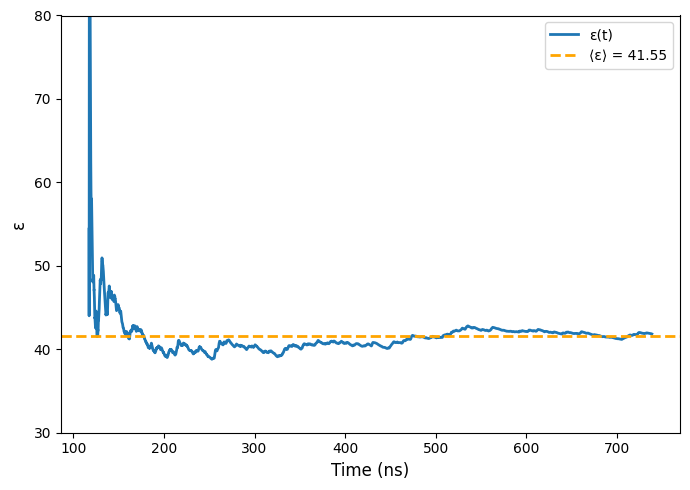

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda


topology = "post_npt.data"
trajectory = "prod_pc.dcd"

T = 298.0  # K
const = 698709  

t_start_ns = 4.0   



u = mda.Universe(topology, trajectory)
atoms = u.atoms
charges = atoms.charges

dipoles = []
volumes = []
times = []

dump_every = 1000     
timestep_fs = 1.0 

for ts in u.trajectory:
    r = atoms.positions          # Å
    M = np.sum(charges[:, None] * r, axis=0)  # e·Å
    dipoles.append(M)
    volumes.append(ts.volume)    # Å^3
    times.append(ts.time * 1e-3) # fs → ns

dipoles = np.array(dipoles)
volumes = np.array(volumes)
times = np.array(times)

# -----------------------------
# Dielectric convergence
# -----------------------------
M2 = np.sum(dipoles**2, axis=1)

eps_t = []
for i in range(1, len(M2) + 1):
    eps = 1.0 + (const / (np.mean(volumes[:i]) * T)) * np.mean(M2[:i])
    eps_t.append(eps)

eps_t = np.array(eps_t)

# -----------------------------
# Plateau averaging
# -----------------------------
mask = times >= t_start_ns
eps_mean = np.mean(eps_t[mask])
eps_std = np.std(eps_t[mask])

print(f"Dielectric constant ε = {eps_mean:.2f} ± {eps_std:.2f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(times, eps_t, lw=2, label="ε(t)")
plt.axhline(eps_mean, ls="--", color = 'orange', lw=2, label=f"⟨ε⟩ = {eps_mean:.2f}")


plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("ε", fontsize=12)
plt.ylim(30, 80)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load system ----------
u = mda.Universe("data.lammps", "prod_pc.dcd")

# ---------- Select ONE molecule ----------
mol_id = 1   
mol = u.select_atoms(f"molnum {mol_id}")

# ---------- Storage ----------
mx, my, mz = [], [], []
time_ns = []

# ---- time between frames (MANUAL!) ----
dt_frame_ns = 0.001  # 1 ps = 0.001 ns

# ---------- Loop ----------
for i, ts in enumerate(u.trajectory):
    r = mol.positions    # Å
    q = mol.charges      # e

    mu = np.sum(q[:, None] * r, axis=0)  # e·Å

    mx.append(mu[0])
    my.append(mu[1])
    mz.append(mu[2])

    time_ns.append(i * dt_frame_ns)

mx = np.array(mx)
my = np.array(my)
mz = np.array(mz)
time_ns = np.array(time_ns)

# ---------- Convert to Debye ----------
eA_to_D = 4.80320427
mx *= eA_to_D
my *= eA_to_D
mz *= eA_to_D

# ---------- Plot ----------
plt.figure(figsize=(8, 5))

plt.plot(time_ns, mx, lw=0.8, label="X component", color="black")
plt.plot(time_ns, my, lw=0.8, label="Y component", color="red")
plt.plot(time_ns, mz, lw=0.8, label="Z component", color="blue")

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Dipole moment (Debye)", fontsize=12)
plt.title(f"Dipole moment of one PC molecule (ID={mol_id})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


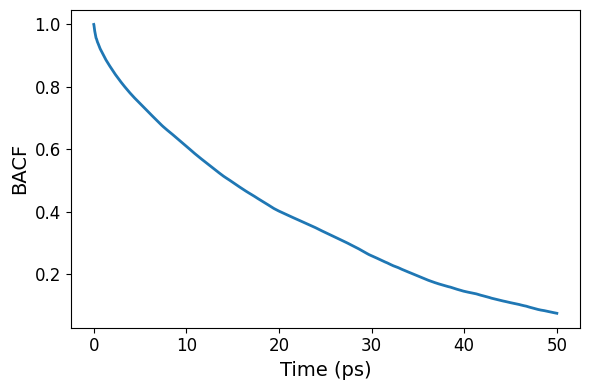

In [6]:

def read_lammps_acf_block(filename, block=-1):
    """
    Read a selected ACF block from fix ave/correlate file.

    Parameters
    ----------
    block : int
        window index (0-based). Use -1 for last block.
    """

    blocks = []
    current = []

    with open(filename, "r") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue

            parts = line.split()

            # начало нового блока
            if len(parts) == 2:
                if current:
                    blocks.append(current)
                current = []
                continue

            if len(parts) == 6:
                current.append([
                    float(parts[1]),  # lag
                    float(parts[3]),  # Cxx
                    float(parts[4]),  # Cyy
                    float(parts[5]),  # Czz
                ])

    if current:
        blocks.append(current)

    if block < 0:
        block = len(blocks) + block

    if block < 0 or block >= len(blocks):
        raise IndexError(f"Block {block} out of range (0..{len(blocks)-1})")

    data = np.array(blocks[block])

    lag = data[:, 0]
    Cx = data[:, 1]
    Cy = data[:, 2]
    Cz = data[:, 3]

    return lag, Cx, Cy, Cz



lag, Cx, Cy, Cz = read_lammps_acf_block("dipole_acf.dat", block=-1)

C = Cx + Cy + Cz
C /= C[0]

time_ps = lag * 1.0e-3  # timestep = 1 fs

plt.figure(figsize=(6,4))
plt.plot(time_ps, C, lw=2)

plt.xlabel("Time (ps)", fontsize=14)
plt.ylabel("ВACF", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
